# Position of quasar

In [1]:
import scipy.stats
from scipy.stats import norm
from scipy.stats import uniform
from astroML import stats as astroMLstats
import numpy as np
from matplotlib import pyplot as plt
import math

Generate fake measurements

(array([0.08052072, 0.04026036, 0.04026036, 0.        , 0.04026036,
        0.08052072, 0.24156215, 0.28182251, 0.12078107, 0.16104143,
        0.36234322, 0.52338466, 0.44286394, 0.60390537, 0.64416573,
        0.92598824, 1.00650895, 1.57015397, 0.88572788, 1.20781075,
        1.65067469, 1.69093504, 1.89223684, 2.29484042, 1.48963325,
        2.13379898, 2.33510078, 1.57015397, 2.2143197 , 2.01301791,
        1.12729003, 1.7311954 , 1.57015397, 1.12729003, 1.12729003,
        1.08702967, 0.68442609, 0.72468645, 0.4831243 , 0.76494681,
        0.40260358, 0.16104143, 0.24156215, 0.20130179, 0.        ,
        0.08052072, 0.        , 0.04026036, 0.08052072, 0.08052072]),
 array([0.35584659, 0.38068492, 0.40552325, 0.43036157, 0.4551999 ,
        0.48003823, 0.50487656, 0.52971489, 0.55455322, 0.57939155,
        0.60422987, 0.6290682 , 0.65390653, 0.67874486, 0.70358319,
        0.72842152, 0.75325984, 0.77809817, 0.8029365 , 0.82777483,
        0.85261316, 0.87745149, 0.90228982, 0.

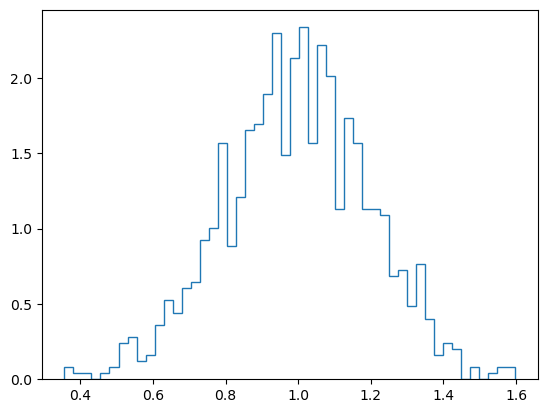

In [2]:
N=1000
mu=1
sigma=0.2
xi=np.random.normal(loc=mu, scale=sigma, size=N)

plt.hist(xi,bins=50,histtype='step', density=True)

Plot the individual likelihoods separately

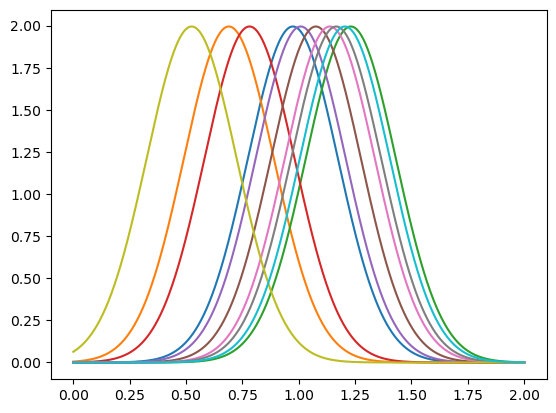

In [3]:
xplot = np.linspace(0, 2, 1000)

for i in range (0,10):
    dist = norm(xi[i], sigma)
    plt.plot(xplot, dist.pdf(xplot))

p=[]
for i in range (0,N):
    dist = norm(xi[0], sigma)
    p.append(dist.pdf(xplot))

Compute and plot the lnL of the dataset (likelihood=product of the likelihoods)

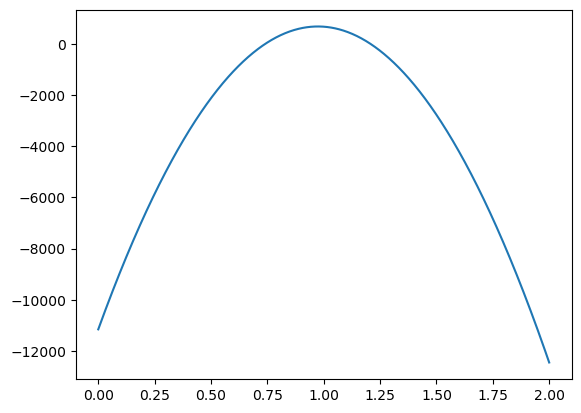

In [4]:
lnL=np.zeros(N)
lnL[0]=0
for i in range (0,N):
    for j in range (1,N):
        lnL[i]=lnL[i] + np.log(p[j][i])
        
plt.plot(xplot, lnL)

Find the maximum of the lnL

In [5]:
max=xplot[lnL.argmax()]
max

0.974974974974975

Compare the max of the lnL with the MLE estimator

In [6]:
mean=np.mean(xi)
mean

0.994329246160031

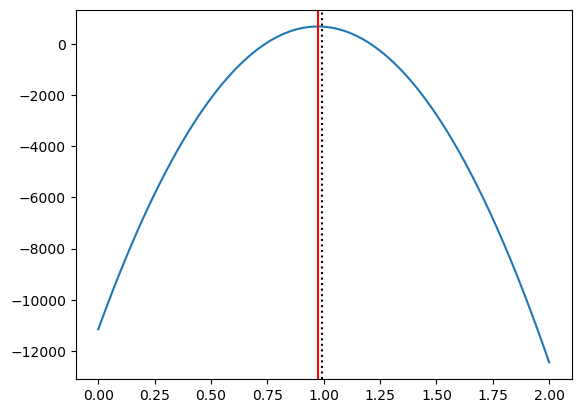

In [7]:
plt.plot(xplot, lnL)
plt.axvline(max,c='red')
plt.axvline(mean,c='black',ls='dotted')

Compute the Fisher matrix error

In [8]:
delta_theta=np.diff(xplot, n=1)
delta_theta=np.delete(delta_theta, 998)
corr_matrix=np.sqrt((-np.diff(lnL, n=2)/(delta_theta**2)))**(-1)
corr_matrix[0]

0.006327719968567266

Compare it with the estimator

In [9]:
sigma_mu=sigma/np.sqrt(N)
sigma_mu

0.006324555320336759

Plot the "measured" likelihood and the numerical likelihood distribution

(0.75, 1.25)

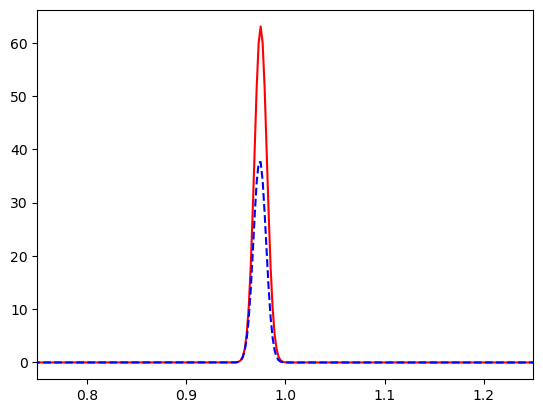

In [10]:
distG=scipy.stats.norm(loc=max, scale=corr_matrix[0])
plt.plot(xplot, distG.pdf(xplot), color="red") #measured
plt.plot(xplot, ((math.e)**lnL)/1e298, color="blue", linestyle="dashed") #numerical

plt.xlim(0.75,1.25)